In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

import matplotlib.pyplot as plt
from tqdm import tqdm

In [60]:
DEVICE = torch.device("mps")
# DEVICE = torch.device("cpu")
BATCH_SIZE=256

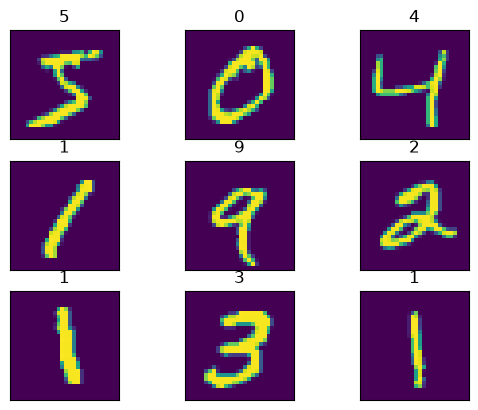

In [61]:
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.1307, ), std=(0.3081, ))
])

ds_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transforms,
    download=True # ?
)
ds_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transforms,
    download=True # ?
)
dl_train = torch.utils.data.DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = torch.utils.data.DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

fig, axs = plt.subplots(3, 3)
axs = axs.flatten()
for i in range(9):
    ax = axs[i]
    ax.imshow(ds_train.data[i])
    ax.set_title(ds_train.targets[i].item())
    ax.set_yticks([])
    ax.set_xticks([])

## Baseline

In [4]:
ds_train.data[0].dtype, ds_train.targets[0].dtype

(torch.uint8, torch.int64)

In [35]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 784),
            nn.ReLU(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.model(x)


def train(model: nn.Module, dl: torch.utils.data.DataLoader, epochs:int = 10, lr=1e-3):
    model.train()
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    loop = tqdm(range(epochs))
    for _ in loop:
        avg_loss = 0
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            optim.zero_grad()
            y_pred = model.forward(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()

            avg_loss += loss * x.size(0)
        avg_loss /= len(dl.dataset)
        losses.append(avg_loss.detach().cpu())
        loop.set_postfix({"mean_loss": avg_loss.item()})

    plt.plot(losses)


def evaluate(model: nn.Module, dl: torch.utils.data.DataLoader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    avg_loss = 0
    correct_count = 0
    with torch.no_grad():
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            y_pred = model.forward(x)
            loss = loss_fn(y_pred, y)
            avg_loss += loss * x.size(0)

            correct_count += (y == torch.softmax(y_pred, dim=1).argmax(1)).sum()

        avg_loss /= len(dl.dataset)
    print(f"Test Loss: {avg_loss}")
    print(f"Test Acc: {correct_count / len(dl.dataset)}")

100%|██████████| 100/100 [03:10<00:00,  1.91s/it, mean_loss=5.75e-5]


Test Loss: 0.08739889413118362
Test Acc: 0.982699990272522


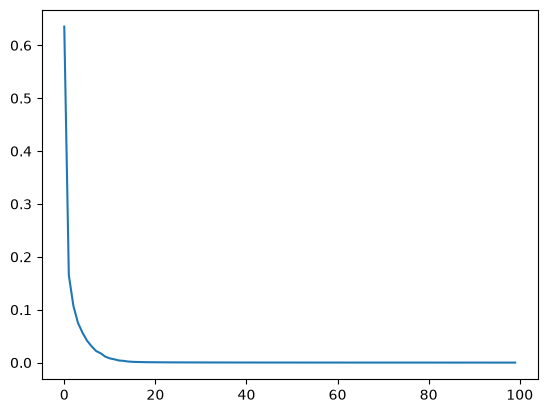

In [21]:
model = BaselineModel().to(DEVICE)
train(model, dl_train)
evaluate(model, dl_test)

## Dropout

In [22]:
class DropoutModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 784),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(784, 256),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.Dropout(0.5),
        )

    def forward(self, x):
        return self.model(x)


around 0.978 w/ dropout on hidden layers, 10 epochs

100 epochs
no dropout:
```
100%|██████████| 100/100 [03:10<00:00,  1.91s/it, mean_loss=5.75e-5]
Test Loss: 0.08739889413118362
Test Acc: 0.982699990272522
```

100 epochs w/ dropout
```
100%|██████████| 100/100 [03:17<00:00,  1.97s/it, mean_loss=0.846]
Test Loss: 0.058771464973688126
Test Acc: 0.98580002784729
```

100%|██████████| 100/100 [03:17<00:00,  1.97s/it, mean_loss=0.846]


Test Loss: 0.058771464973688126
Test Acc: 0.98580002784729


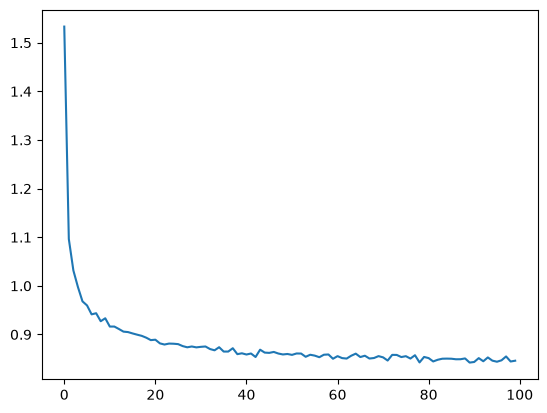

In [23]:
model = DropoutModel().to(DEVICE)
train(model, dl_train)
evaluate(model, dl_test)

## BatchNorm

at 10 epochs, 1e-3 * 16,  baseline gets 0.982, batchnorm 0.984


at 10 epochs 1e-3 * 64, baseline gets 0.982, batchnorm 0.986

at 10 epochs 1e-3 * 256, baseline gets 0.975, batchnorm 0.983

In [47]:
class BatchNormModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

100%|██████████| 10/10 [00:18<00:00,  1.86s/it, mean_loss=0.0335]


Test Loss: 0.12280577421188354
Test Acc: 0.9747999906539917


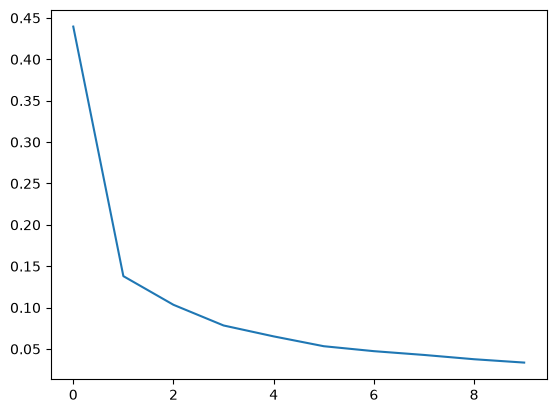

In [43]:
model = BaselineModel().to(DEVICE)
train(model, dl_train, 10, 1e-3 * 256)
evaluate(model, dl_test)

100%|██████████| 10/10 [04:57<00:00, 29.78s/it, mean_loss=0.258]


Test Loss: 0.19859999418258667
Test Acc: 0.9684000015258789


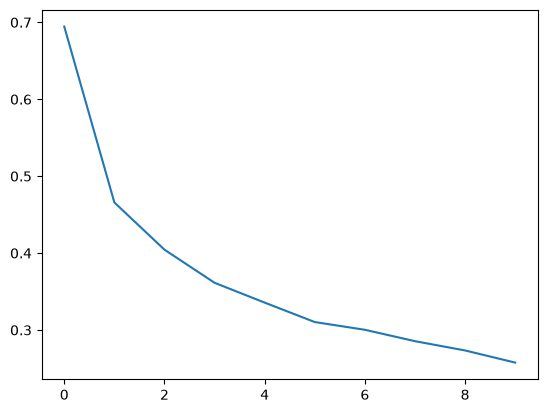

In [57]:
model = BatchNormModel().to(DEVICE)
train(model, dl_train, 10, 1e-3 / 4)
evaluate(model, dl_test)

## LayerNorm

10 epoch 1e-3 16 -> 0.982

10 epoch 1e-3 64 -> 0.982


---

now try batch size 4, LR 1e-3 / 4 (linear scaling)

> Note that `BATCH_SIZE` was temporarily set to 4 to support this

In theory, LayerNorm should work better with very small batch sizes. At least, more robust than BatchNorm.

**LayerNorm case**
```
100%|██████████| 10/10 [04:22<00:00, 26.27s/it, mean_loss=0.00151]
Test Loss: 0.059712108224630356
Test Acc: 0.984000027179718
```

**BatchNorm case**

```
100%|██████████| 10/10 [04:57<00:00, 29.78s/it, mean_loss=0.258]
Test Loss: 0.19859999418258667
Test Acc: 0.9684000015258789
```

-> Seems like LayerNorm indeed performs better in this small-batch size regime



In [48]:
class LayerNormModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 768),
            nn.LayerNorm(768),
            nn.ReLU(),
            nn.Linear(768, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [04:22<00:00, 26.27s/it, mean_loss=0.00151]


Test Loss: 0.059712108224630356
Test Acc: 0.984000027179718


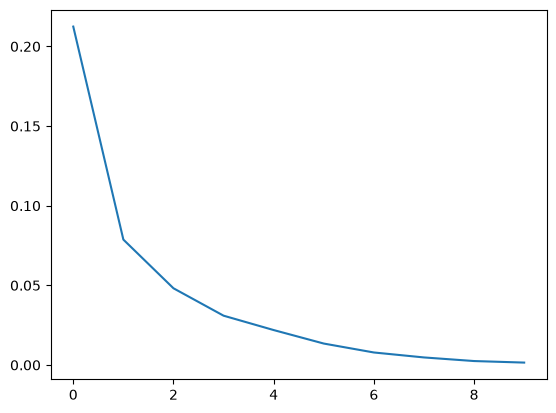

In [56]:
model = LayerNormModel().to(DEVICE)
train(model, dl_train, 10, lr=1e-3 / 4)
evaluate(model, dl_test)

## Residual Connection


```
train(model, dl_train, 10, 1e-3 * 64)

>

model = ResidualModel().to(DEVICE)
train(model, dl_train, 10, 1e-3 * 64)
evaluate(model, dl_test)
```

In [108]:
class ResidualModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(28 * 28, 784)
        self.ln1 = nn.LayerNorm(784)
        self.layer2 = nn.Linear(784, 256)
        self.ln2 = nn.LayerNorm(256)
        self.layer3 = nn.Linear(256, 128)
        self.ln3 = nn.LayerNorm(128)
        self.layer4 = nn.Linear(128, 10)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.flatten(1)
        x1 = self.ln1(self.layer1(x)).relu()
        x1 = x1 + x  # Residual step
        x2 = self.ln2(self.layer2(x1)).relu()
        x3 = self.ln3(self.layer3(x2)).relu()
        x4 = self.layer4(x3)
        return x4
        

100%|██████████| 10/10 [00:21<00:00,  2.12s/it, mean_loss=0.00675]


Test Loss: 0.07444029301404953
Test Acc: 0.9815999865531921


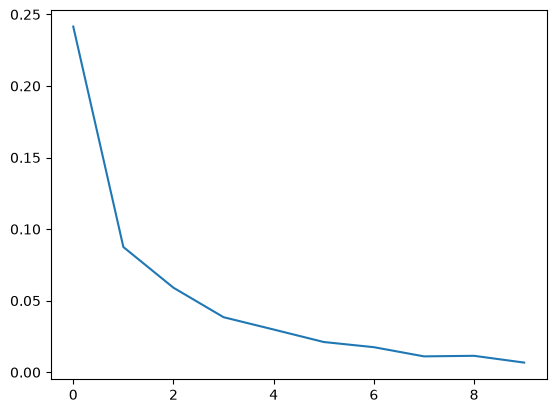

In [109]:
model = ResidualModel().to(DEVICE)
train(model, dl_train, 10, 1e-3 * 64)
evaluate(model, dl_test)


## LR Scheduler

Baseline model, lr_start = 1e-3 * 64 10 epochs
```
100%|██████████| 10/10 [00:19<00:00,  1.98s/it, mean_loss=0.00756]
Test Loss: 0.07840944081544876
Test Acc: 0.9817000031471252
```

w/ scheduler, gamma =0.1 , step = 5 (so one step in 10 epochs)
```
100%|██████████| 10/10 [00:19<00:00,  1.94s/it, avg_loss=0.00335]
Test Loss: 0.05499552562832832
Test Acc: 0.9854999780654907
```


0.982 -> 0.985 !!

100%|██████████| 10/10 [00:19<00:00,  1.98s/it, mean_loss=0.00756]


Test Loss: 0.07840944081544876
Test Acc: 0.9817000031471252


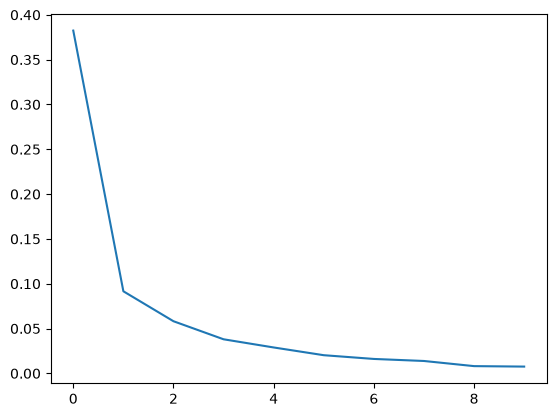

In [106]:
# Baseline again
model = BaselineModel().to(DEVICE)
train(model, dl_train, 10, 1e-3 * 64)
evaluate(model, dl_test)

100%|██████████| 10/10 [00:19<00:00,  1.94s/it, avg_loss=0.00335]


Test Loss: 0.05499552562832832
Test Acc: 0.9854999780654907


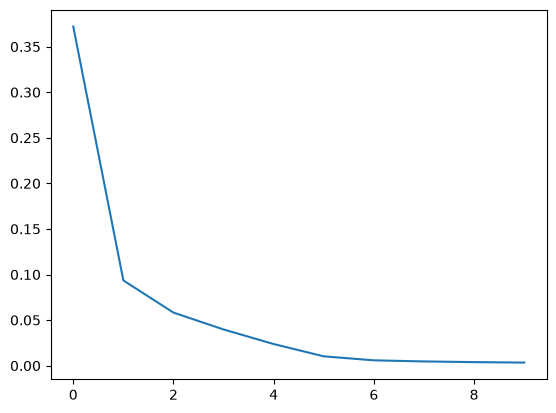

In [107]:
def train_with_scheduler(model, dl, epochs = 10, lr_start=1e-3 * 16, gamma = 0.1):
    optim = torch.optim.SGD(model.parameters(), lr=lr_start, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=5, gamma=gamma)
    loss_fn = nn.CrossEntropyLoss()
    
    pbar = tqdm(range(epochs))
    losses = []
    for _ in pbar:
        avg_loss = 0
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            
            optim.zero_grad()
            y_pred = model.forward(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            avg_loss += loss * x.size(0)
            
        scheduler.step()
        avg_loss /= len(dl.dataset)
        losses.append(avg_loss.detach().cpu())
        pbar.set_postfix({"avg_loss": avg_loss.item()})
    
    plt.plot(losses)
        
model = BaselineModel().to(DEVICE)
train_with_scheduler(model, dl_train, 10, 1e-3 * 64, 0.1)
evaluate(model, dl_test)

## Bad init

with std = 0.01, performance close to baseline

0.1, drops ~0.5%

with std=0.5, totally fails to train!

In [127]:
class PoorInitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 784),
            nn.ReLU(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.model(x)
    
@torch.no_grad()
def poorly_init_weights(m: nn.Module, std=0.5):
    if not isinstance(m, nn.Linear):
        return
    nn.init.normal_(m.weight, 0, std=std)

100%|██████████| 10/10 [00:18<00:00,  1.88s/it, mean_loss=0.0118]


Test Loss: 0.0644192099571228
Test Acc: 0.9803000092506409


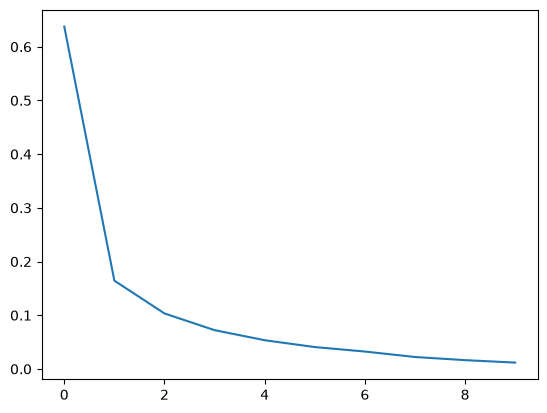

In [111]:
# baseline
model = BaselineModel().to(DEVICE)
train(model, dl_train, 10, 1e-3 * 16)
evaluate(model, dl_test)

100%|██████████| 10/10 [00:19<00:00,  1.90s/it, mean_loss=2.3]    


Test Loss: 2.3010735511779785
Test Acc: 0.11349999904632568


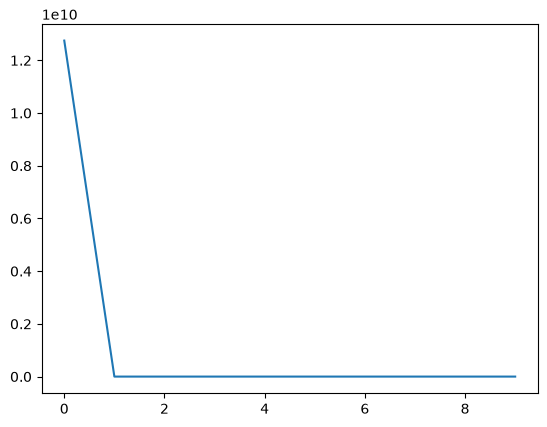

In [ ]:
# poor
model = PoorInitModel().to(DEVICE)
model.apply(poorly_init_weights)
train(model, dl_train, 10 , 1e-3 * 16)
evaluate(model, dl_test)

## Inspector activations w/ different inits

In [172]:
def get_activations(model, x, activations):

    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach().cpu()
        return hook
    
    handles = []
    layer_idx = 0
    for layer in model.model:
        if isinstance(layer, nn.Linear):
            handle = layer.register_forward_hook(get_activation(f"layer_{layer_idx}"))
            layer_idx += 1
            handles.append(handle)

    model.forward(x)
    
    # cleanup
    for handle in handles:
        handle.remove()

In [173]:
x, _ = ds_train[0]
x = x.to(DEVICE)

model = BaselineModel().to(DEVICE)
default_activations = {}
get_activations(model, x, default_activations)

model.apply(poorly_init_weights)
poor_activations = {}
get_activations(model, x, poor_activations)

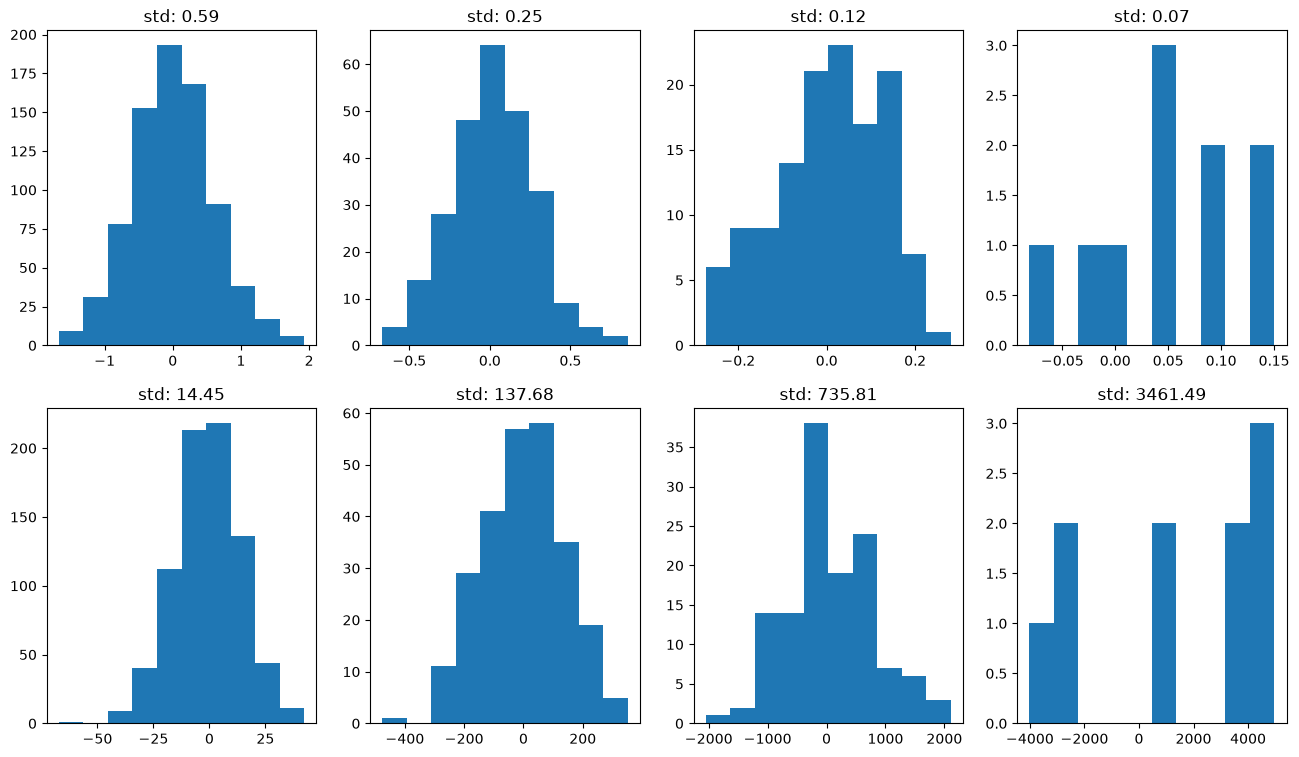

In [174]:
fig, axs = plt.subplots(2, 4)
fig.set_size_inches(16, 9)

# default
for i in range(4):
    acts = default_activations[f'layer_{i}'].flatten()
    axs[0, i].hist(acts)
    axs[0, i].set_title(f"std: {acts.std():.2f}")

# poor
for i in range(4):
    acts = poor_activations[f'layer_{i}'].flatten()
    axs[1, i].hist(acts)
    axs[1, i].set_title(f"std: {acts.std():.2f}")